# Exploración de datos — Colector RENFE Cercanías (TFM)

**Ubicación**: este notebook debe estar en la **raíz del proyecto** (`renfe-collector/explora.ipynb`,
al lado del README), porque todas las rutas son relativas a `data/`.

**Requisitos previos**:
1. Haber capturado datos (`collector.py`, configuración 1 o 3 de VS Code).
2. Haber compactado el/los día(s) a Parquet (`compact_day.py`, configuración 5).
3. Kernel: seleccionar el intérprete del `.venv` del proyecto (arriba a la derecha).


In [2]:
# Dependencia de gráficos (solo la primera vez; tarda unos segundos)
%pip install pandas pyarrow matplotlib -q


Note: you may need to restart the kernel to use updated packages.


In [3]:
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

PROCESSED = Path('data/processed')

def cargar(feed: str) -> pd.DataFrame:
    """Carga y concatena TODOS los parquets diarios disponibles de un feed."""
    files = sorted((PROCESSED / feed).glob(f'{feed}_*.parquet'))
    if not files:
        raise FileNotFoundError(
            f'No hay parquets en {PROCESSED/feed}. '
            'Ejecuta antes la compactación (configuración 5 de VS Code).')
    df = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)
    df['fetched_at_utc'] = pd.to_datetime(df['fetched_at_utc'])
    print(f'{feed}: {len(files)} día(s), {len(df):,} filas')
    return df

tu = cargar('trip_updates')
vp = cargar('vehicle_positions')
al = cargar('alerts')


trip_updates: 1 día(s), 11,932 filas
vehicle_positions: 1 día(s), 11,014 filas
alerts: 1 día(s), 35,656 filas


## 1. Vistazo general a las tablas


In [4]:
tu.head(15)  # una fila por tren-parada-snapshot; el target es arrival/departure_delay_s


,fetched_at_utc,feed_timestamp,entity_id,trip_id,route_id,start_date,start_time,trip_schedule_relationship,trip_update_timestamp,stop_id,stop_sequence,arrival_delay_s,arrival_time,departure_delay_s,departure_time,stop_schedule_relationship
0,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3060V23559C1,3060V23559C1,None,None,None,SCHEDULED,None,51003,<NA>,180,1781278669,<NA>,None,NaN
1,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3060V23554C1,3060V23554C1,None,None,None,SCHEDULED,None,51103,<NA>,720,1781278929,<NA>,None,NaN
2,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3060V83731C5,3060V83731C5,None,None,None,SCHEDULED,None,43005,<NA>,0,1781279280,<NA>,None,NaN
3,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3060V23561C1,3060V23561C1,None,None,None,SCHEDULED,None,51112,<NA>,120,1781279176,<NA>,None,NaN
4,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3060V36112C3,3060V36112C3,None,None,None,SCHEDULED,None,40119,<NA>,0,1781280420,<NA>,None,NaN
5,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3060V23558C1,3060V23558C1,None,None,None,SCHEDULED,None,50602,<NA>,120,1781278830,<NA>,None,NaN
6,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3060V23071C2,3060V23071C2,None,None,None,SCHEDULED,None,51050,<NA>,0,1781279280,<NA>,None,NaN
7,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3160V23443T1,3160V23443T1,None,None,None,SCHEDULED,None,51463,<NA>,1260,1781278620,<NA>,None,NaN
8,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3160V23235C1,3160V23235C1,None,None,None,SCHEDULED,None,51409,<NA>,1680,1781278680,<NA>,None,NaN
9,2026-06-12 15:37:32.336562+00:00,1781278645,TUUPDATE_3160V23444T1,3160V23444T1,None,None,None,SCHEDULED,None,51414,<NA>,180,1781278620,<NA>,None,NaN


In [5]:
vp.head(10)  # posición y estado de cada tren en cada snapshot


,fetched_at_utc,feed_timestamp,entity_id,vehicle_id,vehicle_label,trip_id,route_id,latitude,longitude,bearing,speed,current_status,current_stop_sequence,stop_id,vehicle_timestamp
0,2026-06-12 15:37:32.336562+00:00,1781278645,VP_C1-23559,23559,C1-23559-PLATF.(8),3060V23559C1,None,37.392567,-5.974984,None,None,INCOMING_AT,<NA>,51003,1781278637
1,2026-06-12 15:37:32.336562+00:00,1781278645,VP_C1-23554,23554,C1-23554-PLATF.(2),3060V23554C1,None,37.318400,-5.965496,None,None,IN_TRANSIT_TO,<NA>,51111,1781278637
2,2026-06-12 15:37:32.336562+00:00,1781278645,VP_C5-23731,23731,C5-23731-PLATF.(3),3060V83731C5,None,37.356940,-6.208262,None,None,INCOMING_AT,<NA>,43005,1781278637
3,2026-06-12 15:37:32.336562+00:00,1781278645,VP_C1-23558,23558,C1-23558-PLATF.(2),3060V23558C1,None,37.581570,-5.669962,None,None,INCOMING_AT,<NA>,50602,1781278637
4,2026-06-12 15:37:32.336562+00:00,1781278645,VP_C2-23071,23071,C2-23071-PLATF.(1),3060V23071C2,None,37.407430,-6.009991,None,None,INCOMING_AT,<NA>,51050,1781278637
5,2026-06-12 15:37:32.336562+00:00,1781278645,VP_C1-23561,23561,C1-23561,3060V23561C1,None,37.196533,-5.802129,None,None,IN_TRANSIT_TO,<NA>,51200,1781278637
6,2026-06-12 15:37:32.336562+00:00,1781278645,VP_C3-23112,23112,C3-23112,3060V36112C3,None,37.831806,-5.768918,None,None,IN_TRANSIT_TO,<NA>,40115,1781278637
7,2026-06-12 15:37:32.336562+00:00,1781278645,VP_T1-23443,23443,T1-23443-PLATF.(1),3160V23443T1,None,36.455963,-6.209636,None,None,INCOMING_AT,<NA>,51463,1781278637
8,2026-06-12 15:37:32.336562+00:00,1781278645,VP_C1-23235,23235,C1-23235-PLATF.(1),3160V23235C1,None,36.502960,-6.272031,None,None,INCOMING_AT,<NA>,51409,1781278637
9,2026-06-12 15:37:32.336562+00:00,1781278645,VP_T1-23444,23444,T1-23444-PLATF.(2),3160V23444T1,None,36.521587,-6.280711,None,None,INCOMING_AT,<NA>,51414,1781278637


In [6]:
al[['fetched_at_utc','entity_id','cause','effect','informed_route_id','header_text']].drop_duplicates('entity_id').head(15)


,fetched_at_utc,entity_id,cause,effect,informed_route_id,header_text
0,2026-06-12 15:37:32.336562+00:00,AVISO_493944,None,NaN,NaN,None
1,2026-06-12 15:37:32.336562+00:00,AVISO_493464,None,NaN,10T0030C3,None
11,2026-06-12 15:37:32.336562+00:00,AVISO_491717,None,NaN,10T0035C5,None
17,2026-06-12 15:37:32.336562+00:00,AVISO_490590,None,NaN,10T0030C3,None
37,2026-06-12 15:37:32.336562+00:00,AVISO_483553,None,NaN,10T0025C9,None
41,2026-06-12 15:37:32.336562+00:00,AVISO_476867,None,NaN,10T0030C3,None
51,2026-06-12 15:37:32.336562+00:00,AVISO_467462,None,NaN,10T0041C8,None
67,2026-06-12 15:37:32.336562+00:00,INFO_493923,None,NaN,NaN,None
68,2026-06-12 15:37:32.336562+00:00,INFO_493835,None,NaN,10T0065C1,None
72,2026-06-12 15:37:32.336562+00:00,INFO_493833,None,NaN,NaN,None


## 2. Los trenes más retrasados capturados


In [7]:
(tu.dropna(subset=['arrival_delay_s'])
   .sort_values('arrival_delay_s', ascending=False)
   [['fetched_at_utc','trip_id','stop_id','stop_sequence','arrival_delay_s','departure_delay_s']]
   .head(20))


,fetched_at_utc,trip_id,stop_id,stop_sequence,arrival_delay_s,departure_delay_s
9098,2026-06-12 17:04:53.348617+00:00,5160V77648R4,78709,<NA>,9360,<NA>
11309,2026-06-12 17:15:55.585106+00:00,5160V77452R4,72208,<NA>,9300,<NA>
11336,2026-06-12 17:15:55.585106+00:00,5160V25668R1,72305,<NA>,6780,<NA>
9085,2026-06-12 17:04:53.348617+00:00,5160V25550R2S,71705,<NA>,5940,<NA>
1030,2026-06-12 15:54:09.926891+00:00,3160V23443T1,51458,<NA>,5280,<NA>
1253,2026-06-12 15:54:19.895684+00:00,3160V23443T1,51458,<NA>,5280,<NA>
1027,2026-06-12 15:54:09.926891+00:00,3160V23235C1,51401,<NA>,5160,<NA>
1250,2026-06-12 15:54:19.895684+00:00,3160V23235C1,51401,<NA>,5160,<NA>
1252,2026-06-12 15:54:19.895684+00:00,3160V23234C1,51401,<NA>,5160,<NA>
1029,2026-06-12 15:54:09.926891+00:00,3160V23234C1,51401,<NA>,5160,<NA>


## 3. AUDITORÍA 1 — ¿Cuántas paradas publica RENFE por tren y snapshot?

Si la mediana es ~1, el feed solo informa la **próxima parada** y la serie temporal
del retraso hay que reconstruirla snapshot a snapshot (lo que justifica el muestreo de 60s).


In [8]:
paradas_por_tren = tu.groupby(['fetched_at_utc','trip_id']).stop_id.count()
paradas_por_tren.describe()


count    11416.000000
mean         1.003416
std          0.727705
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         12.000000
Name: stop_id, dtype: float64

## 4. AUDITORÍA 2 — ¿Se puede reconstruir la evolución del retraso de un tren?


,fetched_at_utc,stop_id,stop_sequence,arrival_delay_s
56,2026-06-12 15:37:32.336562+00:00,72210,<NA>,0
175,2026-06-12 15:39:58.379453+00:00,72210,<NA>,360
389,2026-06-12 15:52:19.566811+00:00,72301,<NA>,60
619,2026-06-12 15:53:09.895855+00:00,72301,<NA>,0
843,2026-06-12 15:53:19.676612+00:00,72301,<NA>,0
1070,2026-06-12 15:54:09.926891+00:00,72301,<NA>,0
1293,2026-06-12 15:54:19.895684+00:00,72301,<NA>,0
1512,2026-06-12 15:55:10.095288+00:00,72301,<NA>,0
1734,2026-06-12 15:55:20.041304+00:00,72301,<NA>,0
1982,2026-06-12 15:56:10.244526+00:00,72302,<NA>,0


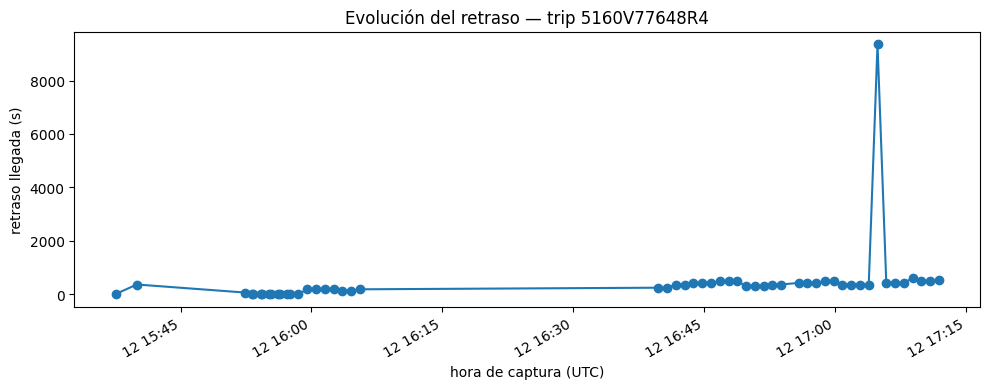

In [9]:
# Tomamos el tren con mayor retraso observado y seguimos su delay a lo largo del tiempo
peor_trip = tu.loc[tu.arrival_delay_s.idxmax(), 'trip_id']
evo = (tu[tu.trip_id == peor_trip]
       .dropna(subset=['arrival_delay_s'])
       .sort_values('fetched_at_utc'))
display(evo[['fetched_at_utc','stop_id','stop_sequence','arrival_delay_s']])

ax = evo.plot(x='fetched_at_utc', y='arrival_delay_s', marker='o', figsize=(10,4),
              title=f'Evolución del retraso — trip {peor_trip}', legend=False)
ax.set_ylabel('retraso llegada (s)'); ax.set_xlabel('hora de captura (UTC)')
plt.tight_layout(); plt.show()


## 5. Distribución del retraso (todas las observaciones)


count       10939.0
mean     319.246732
std      585.969635
min         -2580.0
25%             0.0
50%           120.0
75%           420.0
max          9360.0
Name: arrival_delay_s, dtype: Float64

% observaciones con retraso >= 5 min: 33.3%
% observaciones con retraso >= 15 min: 10.2%
% en hora (|delay| < 60s): 33.7%


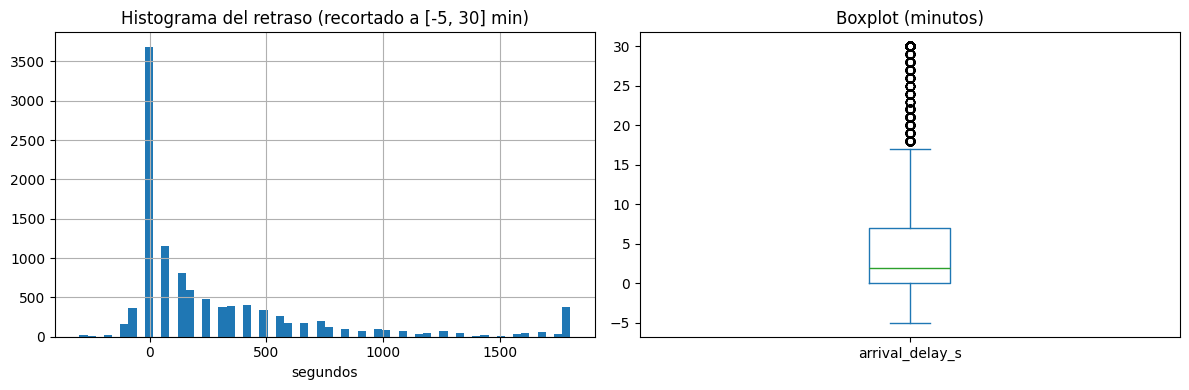

In [10]:
delays = tu.arrival_delay_s.dropna()
print(delays.describe())
print(f'\n% observaciones con retraso >= 5 min: {(delays >= 300).mean():.1%}')
print(f'% observaciones con retraso >= 15 min: {(delays >= 900).mean():.1%}')
print(f'% en hora (|delay| < 60s): {(delays.abs() < 60).mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12,4))
delays.clip(-300, 1800).hist(bins=60, ax=axes[0])
axes[0].set_title('Histograma del retraso (recortado a [-5, 30] min)')
axes[0].set_xlabel('segundos')
delays.clip(-300, 1800).div(60).plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot (minutos)')
plt.tight_layout(); plt.show()


## 6. Retraso por hora del día

Con un solo día esto es solo orientativo; con semanas de datos será una de las
features más importantes del modelo (patrón de hora punta).


,count,median,mean,pct_>=5min
hora_local,,,,
17,2674,60.0,311.286462,0.304787
18,4750,120.0,303.865263,0.340211
19,3515,120.0,346.088193,0.34623


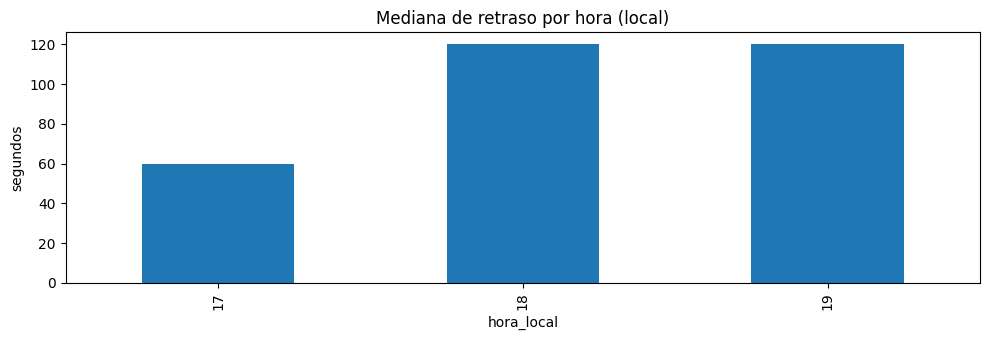

In [13]:
tmp = tu.dropna(subset=['arrival_delay_s']).copy()
ts = tmp.fetched_at_utc
tmp['hora_local'] = (ts.dt.tz_localize('UTC') if ts.dt.tz is None else ts).dt.tz_convert('Europe/Madrid').dt.hour
resumen_hora = tmp.groupby('hora_local').arrival_delay_s.agg(['count','median','mean',
    lambda s: (s>=300).mean()]).rename(columns={'<lambda_0>':'pct_>=5min'})
display(resumen_hora)

ax = resumen_hora['median'].plot(kind='bar', figsize=(10,3.5), title='Mediana de retraso por hora (local)')
ax.set_ylabel('segundos'); plt.tight_layout(); plt.show()


## 7. Mapa rápido de posiciones de los trenes


Último snapshot: 121 trenes | estados: {'STOPPED_AT': 44, 'INCOMING_AT': 39, 'IN_TRANSIT_TO': 38}


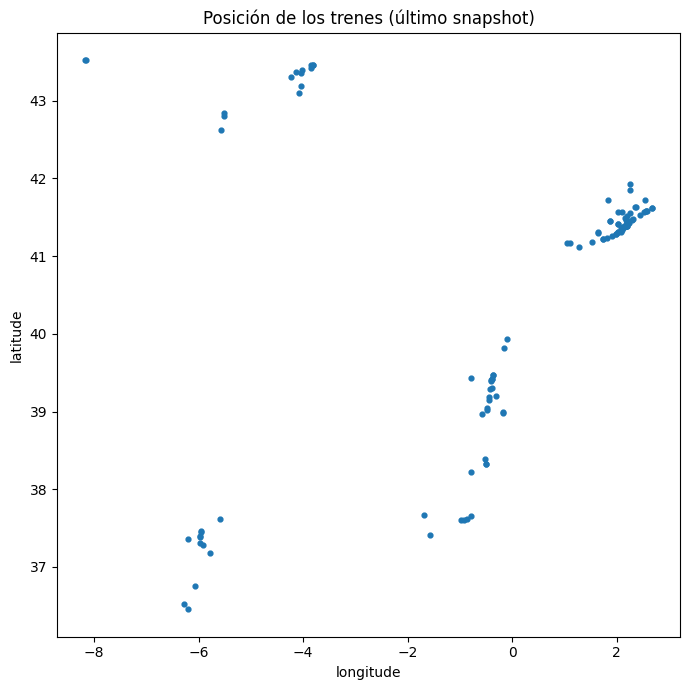

In [14]:
ult = vp[vp.fetched_at_utc == vp.fetched_at_utc.max()].dropna(subset=['latitude','longitude'])
print(f'Último snapshot: {len(ult)} trenes | estados: {ult.current_status.value_counts().to_dict()}')
ax = ult.plot.scatter(x='longitude', y='latitude', s=12, figsize=(7,7),
                      title='Posición de los trenes (último snapshot)')
plt.tight_layout(); plt.show()
# Deberíais reconocer la silueta de los núcleos de Cercanías de España.
# Si solo veis una nube (p.ej. Madrid), tenéis la respuesta a la duda de cobertura.


## 8. AUDITORÍA 3 — Cruce trip_id ↔ GTFS estático (líneas)

El feed no trae `route_id`, así que la línea (C-1, C-4...) sale de cruzar con `trips.txt`
del GTFS estático. Requiere haber ejecutado `download_gtfs_static.py` con la URL corregida.


In [19]:
import zipfile

zips = sorted(Path('data/gtfs_static').glob('gtfs_cercanias_*.zip'))
if not zips:
    print('Aún no hay GTFS estático descargado. Ejecuta la configuración 4 (con la URL corregida).')
else:
    zf = zipfile.ZipFile(zips[-1])
    trips = pd.read_csv(zf.open('trips.txt'), dtype=str)
    routes = pd.read_csv(zf.open('routes.txt'), dtype=str)
    match = tu.trip_id.isin(set(trips.trip_id)).mean()
    print(f'% de trip_ids del feed que casan con el estático: {match:.1%}')
    if match > 0.5:
        enriquecido = tu.merge(trips[['trip_id','route_id']], on='trip_id', how='left') \
                        .merge(routes[['route_id','route_short_name']], on='route_id', how='left')
        print('\nObservaciones de retraso por línea:')
        display(enriquecido.dropna(subset=['arrival_delay_s'])
                .route_short_name.value_counts().head(15))
    else:
        print('Cruce bajo: inspeccionad el formato de trip_id en ambos lados:')
        print('  feed    :', tu.trip_id.dropna().unique()[:5])
        print('  estático:', trips.trip_id.dropna().unique()[:5])


% de trip_ids del feed que casan con el estático: 72.2%


KeyError: 'route_id'

---
**Siguientes pasos**: cuando haya varios días compactados, este mismo notebook ya
mostrará patrones por hora/día. Las celdas 3, 4 y 8 son las que responden las dudas
de la auditoría — pegad sus salidas en el chat para cerrar el diseño del dataset de
entrenamiento antes del borrador del 18.
